In [7]:
# Importar librerías necesarias
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

# Agregar el directorio src al path
sys.path.append(os.path.abspath('../src'))

from config.config import (
    IMAGE_SIZE,
    ROTATION_RANGE,
    ZOOM_RANGE,
    WIDTH_SHIFT_RANGE,
    HEIGHT_SHIFT_RANGE,
    HORIZONTAL_FLIP,
    VERTICAL_FLIP,
    BRIGHTNESS_RANGE,
    ID_COLUMN
)

CSV_PATH = '../data/bcn20000_metadata_2025-07-22.csv'
IMAGES_FOLDER = '../data/ISIC-images/'

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [8]:
# Cargar una imagen de ejemplo del dataset
df = pd.read_csv(CSV_PATH)
print(f"Dataset cargado: {len(df)} imágenes")

# Seleccionar una imagen de ejemplo (puedes cambiar el índice)
sample_idx = 0
image_id = df.iloc[sample_idx][ID_COLUMN]
image_path = os.path.join(IMAGES_FOLDER, f"{image_id}.jpg")

print(f"Imagen de ejemplo: {image_id}")
print(f"Diagnóstico: {df.iloc[sample_idx]['diagnosis_1']}")

Dataset cargado: 18946 imágenes
Imagen de ejemplo: ISIC_0053453
Diagnóstico: Benign


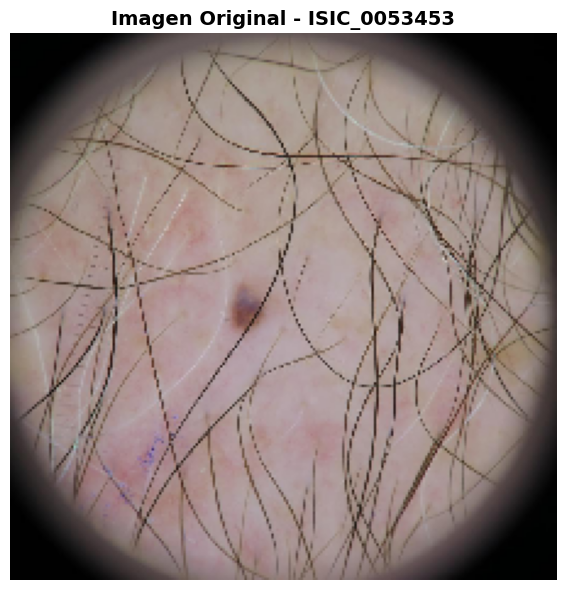

Tamaño de imagen: (224, 224, 3)


In [9]:
# Cargar y mostrar la imagen original
original_img = load_img(image_path, target_size=IMAGE_SIZE)
original_array = img_to_array(original_img)

plt.figure(figsize=(6, 6))
plt.imshow(original_array.astype('uint8'))
plt.title(f'Imagen Original - {image_id}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Tamaño de imagen: {original_array.shape}")

In [10]:
# Crear el generador de data augmentation (SIN preprocesamiento para visualización)
datagen = ImageDataGenerator(
    rotation_range=ROTATION_RANGE,
    zoom_range=ZOOM_RANGE,
    width_shift_range=WIDTH_SHIFT_RANGE,
    height_shift_range=HEIGHT_SHIFT_RANGE,
    horizontal_flip=HORIZONTAL_FLIP,
    vertical_flip=VERTICAL_FLIP,
    brightness_range=BRIGHTNESS_RANGE,
    fill_mode='nearest'
)

print("✅ Generador de augmentation configurado")

✅ Generador de augmentation configurado


Generando ejemplos de data augmentation...



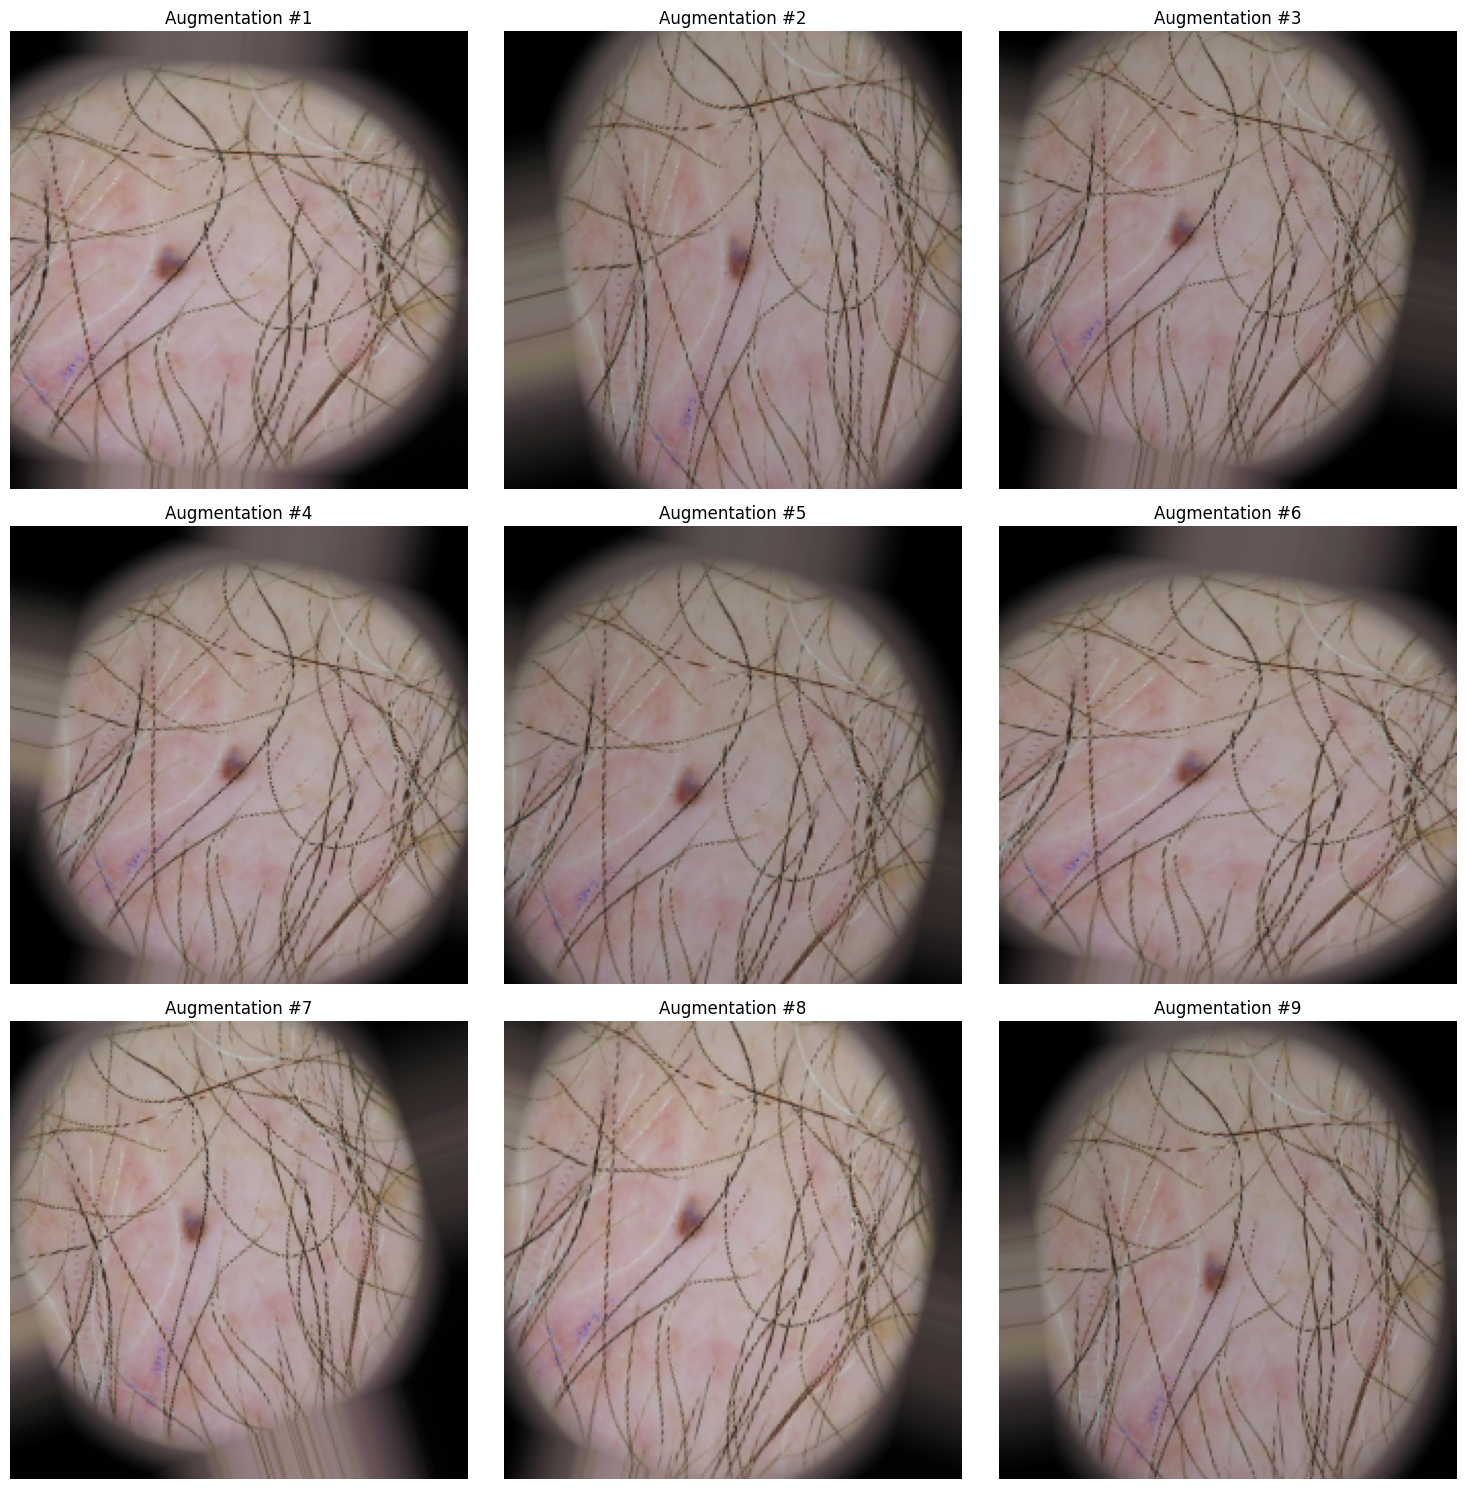

In [11]:
# Generar y visualizar múltiples ejemplos de augmentation
def visualize_augmentation(image_array, datagen, num_examples=9):
    """
    Visualiza múltiples ejemplos de data augmentation aplicados a una imagen.
    
    Args:
        image_array: Array de la imagen original
        datagen: ImageDataGenerator configurado
        num_examples: Número de ejemplos a generar
    """
    # Calcular el grid
    cols = 3
    rows = (num_examples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if num_examples > 1 else [axes]
    
    # Expandir dimensiones para el generador
    img_batch = np.expand_dims(image_array, axis=0)
    
    # Generar transformaciones
    iterator = datagen.flow(img_batch, batch_size=1)
    
    for i in range(num_examples):
        # Obtener imagen transformada
        augmented_img = next(iterator)[0]
        
        # Normalizar para visualización (0-255)
        augmented_img = np.clip(augmented_img, 0, 255).astype('uint8')
        
        # Mostrar
        axes[i].imshow(augmented_img)
        axes[i].set_title(f'Augmentation #{i+1}', fontsize=12)
        axes[i].axis('off')
    
    # Ocultar ejes vacíos si hay alguno
    for i in range(num_examples, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Generar 9 ejemplos
print("Generando ejemplos de data augmentation...\n")
visualize_augmentation(original_array, datagen, num_examples=9)

Comparación Original vs Augmentado:



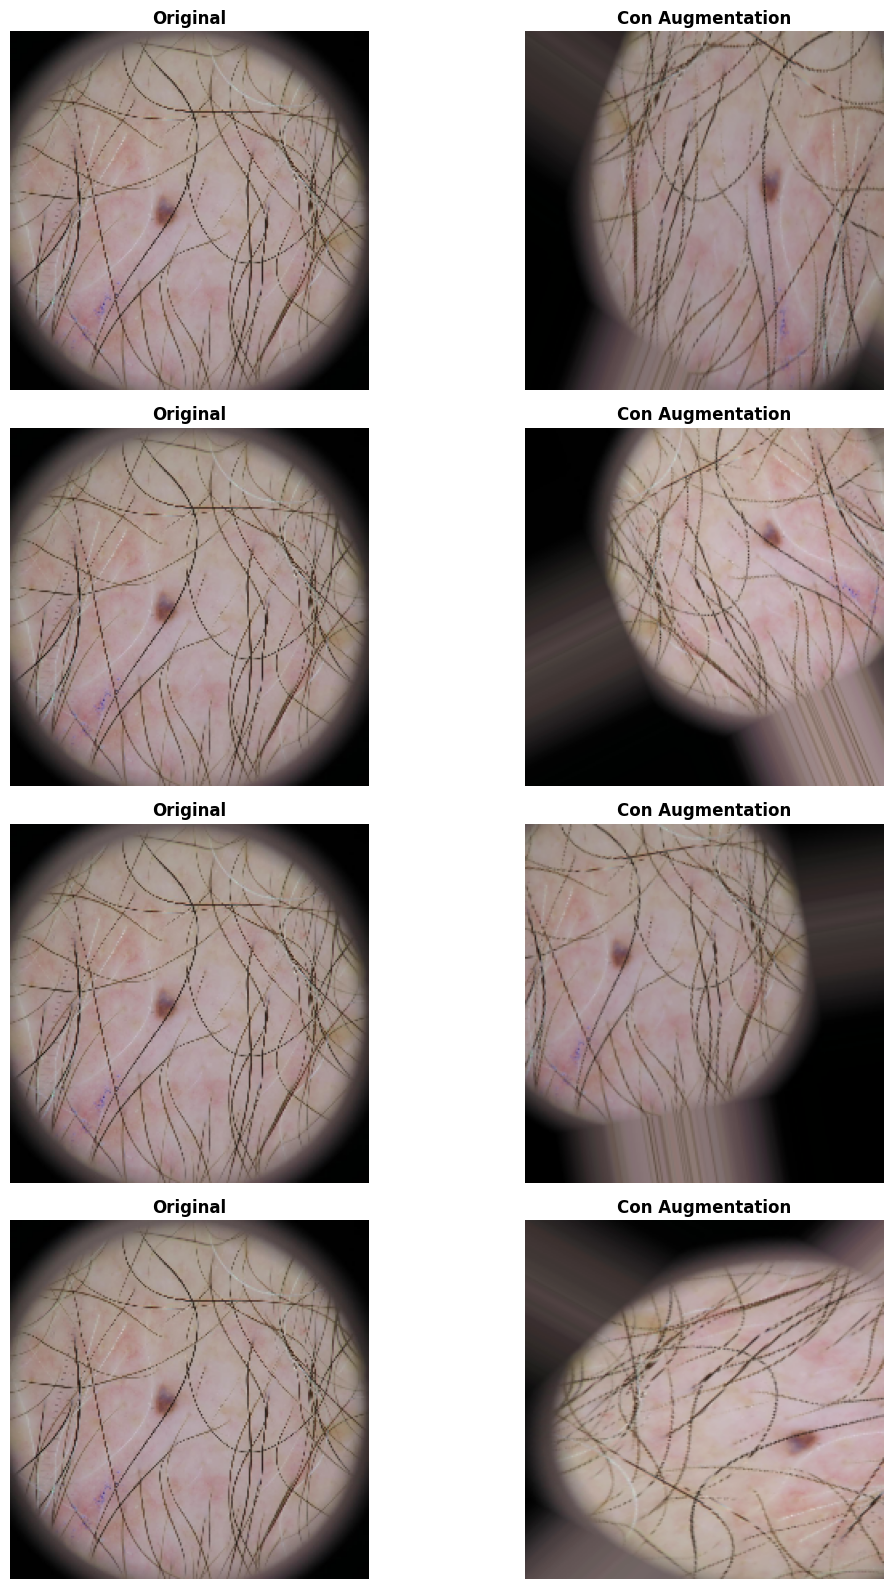

In [12]:
# Comparación lado a lado: Original vs Augmented
def compare_original_augmented(image_array, datagen, num_pairs=4):
    """
    Compara imagen original con versiones augmentadas.
    """
    fig, axes = plt.subplots(num_pairs, 2, figsize=(12, 4 * num_pairs))
    
    img_batch = np.expand_dims(image_array, axis=0)
    iterator = datagen.flow(img_batch, batch_size=1)
    
    for i in range(num_pairs):
        # Original
        axes[i, 0].imshow(image_array.astype('uint8'))
        axes[i, 0].set_title('Original', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Augmented
        augmented_img = next(iterator)[0]
        augmented_img = np.clip(augmented_img, 0, 255).astype('uint8')
        axes[i, 1].imshow(augmented_img)
        axes[i, 1].set_title('Con Augmentation', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Comparación Original vs Augmentado:\n")
compare_original_augmented(original_array, datagen, num_pairs=4)

Visualización de transformaciones individuales:



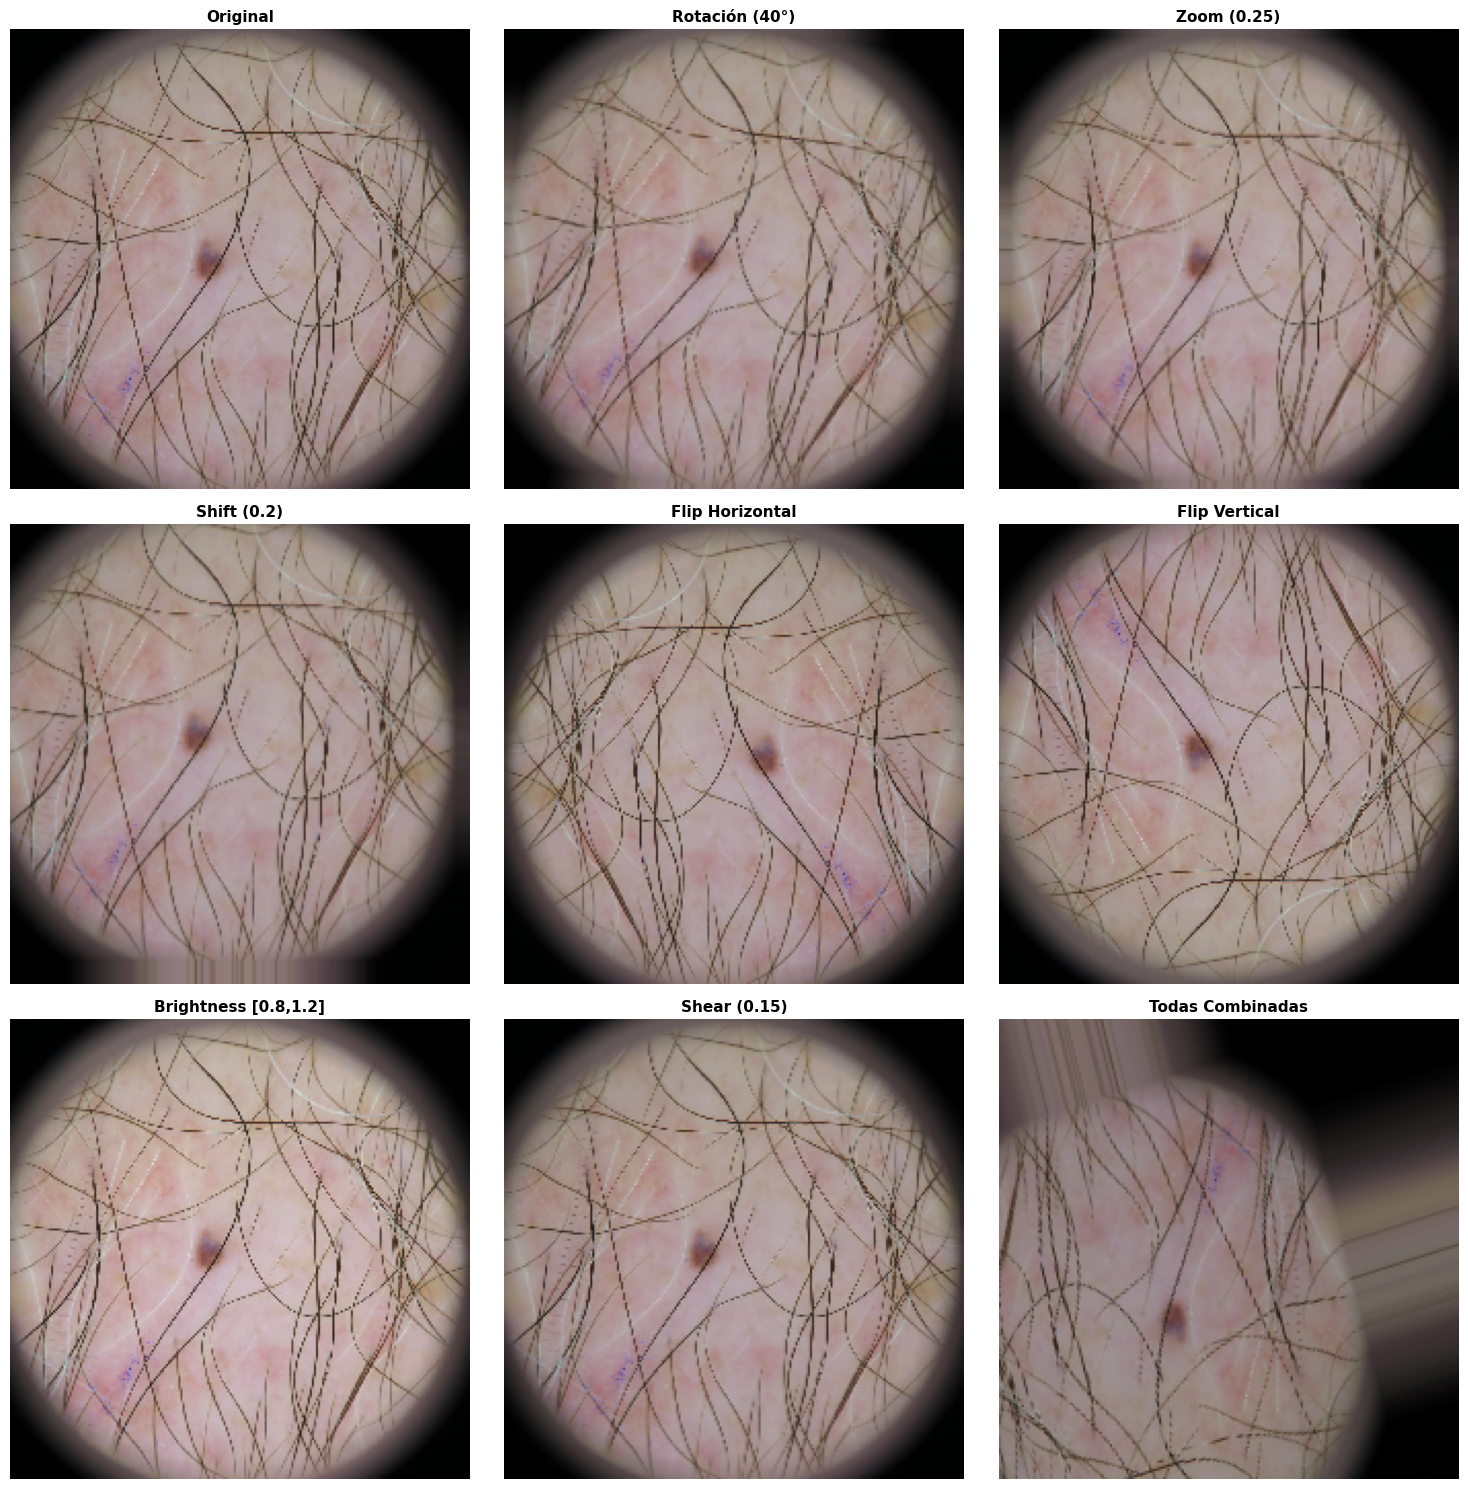

In [13]:
# Visualizar transformaciones específicas por separado
def visualize_specific_transformations(image_array):
    """
    Muestra cada tipo de transformación por separado.
    """
    transformations = [
        ('Original', ImageDataGenerator()),
        ('Rotación (40°)', ImageDataGenerator(rotation_range=ROTATION_RANGE)),
        ('Zoom (0.25)', ImageDataGenerator(zoom_range=ZOOM_RANGE)),
        ('Shift (0.2)', ImageDataGenerator(
            width_shift_range=WIDTH_SHIFT_RANGE,
            height_shift_range=HEIGHT_SHIFT_RANGE
        )),
        ('Flip Horizontal', ImageDataGenerator(horizontal_flip=True)),
        ('Flip Vertical', ImageDataGenerator(vertical_flip=True)),
        ('Brightness [0.8,1.2]', ImageDataGenerator(brightness_range=BRIGHTNESS_RANGE)),
        ('Shear (0.15)', ImageDataGenerator(shear_range=SHEAR_RANGE)),
        ('Todas Combinadas', ImageDataGenerator(
            rotation_range=ROTATION_RANGE,
            zoom_range=ZOOM_RANGE,
            width_shift_range=WIDTH_SHIFT_RANGE,
            height_shift_range=HEIGHT_SHIFT_RANGE,
            horizontal_flip=HORIZONTAL_FLIP,
            vertical_flip=VERTICAL_FLIP,
            brightness_range=BRIGHTNESS_RANGE,
            shear_range=SHEAR_RANGE
        ))
    ]
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()
    
    img_batch = np.expand_dims(image_array, axis=0)
    
    for i, (name, datagen) in enumerate(transformations):
        if name == 'Original':
            img_display = image_array.astype('uint8')
        else:
            iterator = datagen.flow(img_batch, batch_size=1)
            img_display = next(iterator)[0]
            img_display = np.clip(img_display, 0, 255).astype('uint8')
        
        axes[i].imshow(img_display)
        axes[i].set_title(name, fontsize=11, fontweight='bold')
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Visualización de transformaciones individuales:\n")
visualize_specific_transformations(original_array)

Análisis de variabilidad del data augmentation:



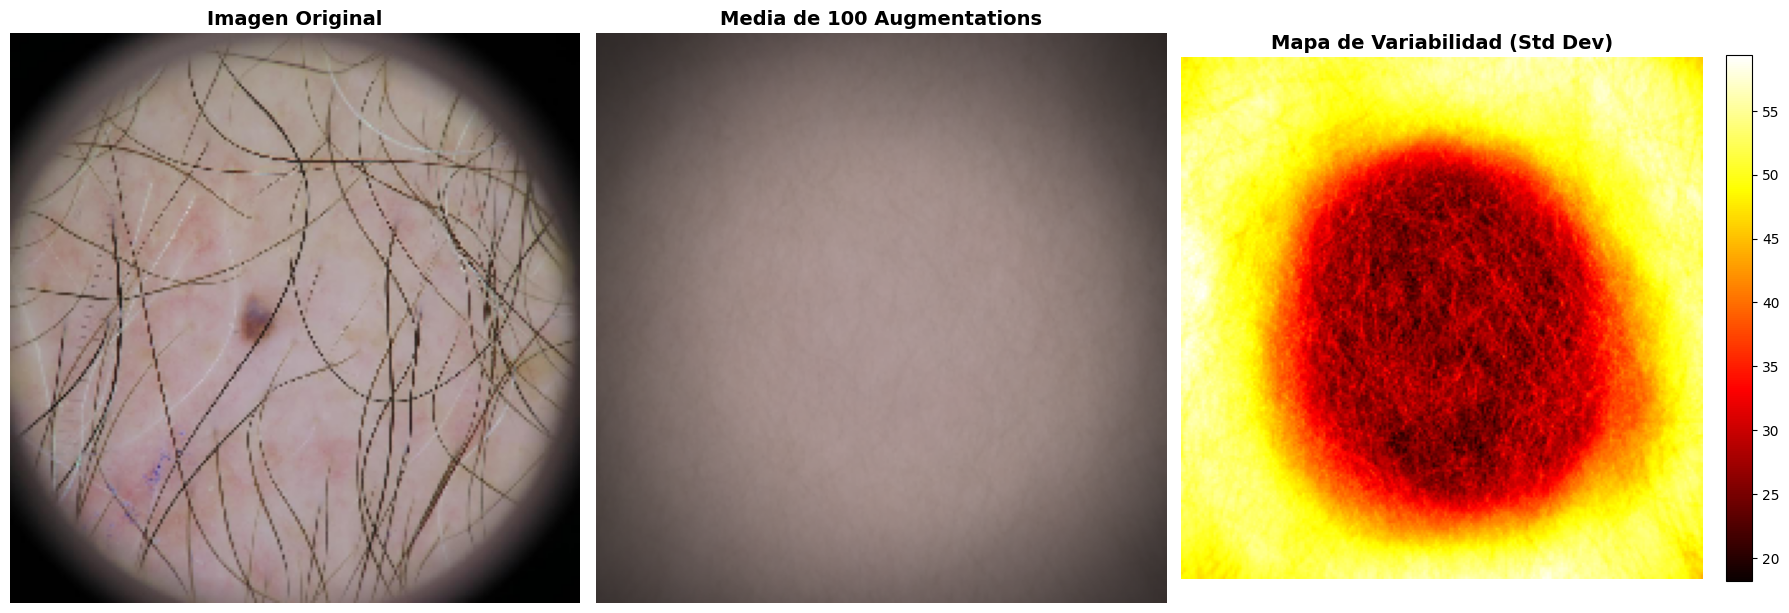


📊 Estadísticas de 100 transformaciones:
   Media de píxeles: 117.02
   Desviación estándar promedio: 42.30
   Variabilidad máxima: 64.90


In [14]:
# Estadísticas de variabilidad
def analyze_augmentation_variability(image_array, datagen, num_samples=100):
    """
    Analiza la variabilidad introducida por el data augmentation.
    """
    img_batch = np.expand_dims(image_array, axis=0)
    iterator = datagen.flow(img_batch, batch_size=1)
    
    # Generar múltiples muestras
    samples = []
    for _ in range(num_samples):
        augmented = next(iterator)[0]
        samples.append(augmented)
    
    samples = np.array(samples)
    
    # Calcular estadísticas
    mean_img = np.mean(samples, axis=0)
    std_img = np.std(samples, axis=0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original
    axes[0].imshow(image_array.astype('uint8'))
    axes[0].set_title('Imagen Original', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Media de augmentations
    axes[1].imshow(np.clip(mean_img, 0, 255).astype('uint8'))
    axes[1].set_title(f'Media de {num_samples} Augmentations', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    # Desviación estándar (mapa de calor)
    std_gray = np.mean(std_img, axis=2)  # Convertir a escala de grises
    im = axes[2].imshow(std_gray, cmap='hot')
    axes[2].set_title('Mapa de Variabilidad (Std Dev)', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Estadísticas de {num_samples} transformaciones:")
    print(f"   Media de píxeles: {np.mean(mean_img):.2f}")
    print(f"   Desviación estándar promedio: {np.mean(std_img):.2f}")
    print(f"   Variabilidad máxima: {np.max(std_img):.2f}")

print("Análisis de variabilidad del data augmentation:\n")
analyze_augmentation_variability(original_array, datagen, num_samples=100)

## 📝 Resumen de Configuración

Este notebook demuestra visualmente cómo las transformaciones de data augmentation:

1. **Aumentan la diversidad** del dataset sin necesidad de más imágenes
2. **Mejoran la generalización** del modelo al exponerlo a variaciones realistas
3. **Reducen el overfitting** al crear "nuevas" muestras en cada época

### Transformaciones aplicadas:
- ✅ Rotación aleatoria hasta 40°
- ✅ Zoom aleatorio hasta 25%
- ✅ Desplazamiento horizontal/vertical hasta 20%
- ✅ Volteo horizontal y vertical
- ✅ Variación de brillo [0.8, 1.2]
- ✅ Shear (inclinación) hasta 0.15

**Nota:** Durante el entrenamiento, estas transformaciones se aplican también con preprocesamiento de ResNet50 (normalización ImageNet).